In [126]:
%reload_ext autoreload
%autoreload 2


In [127]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from processing import crop_faces
from training import (
    CROPS_DIR, BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, VAL_SPLIT, SEED, CHECKPOINT_PATH,
    get_device, build_dataloaders, compute_class_weights, build_model, run_epoch,
)
from evaluation import evaluate_model


## 1. Build the crops dataset

In [128]:
crop_faces(
    image_dir="../data/images",
    annotation_dir="../data/annotations",
    output_dir="../data/crops",
)


Saved 3603 face crops, skipped 469 tiny/degenerate boxes


## 2. Train

In [129]:
torch.manual_seed(SEED)

device = get_device()
print(f"Using device: {device}")

train_loader, val_loader, classes, train_targets = build_dataloaders(CROPS_DIR, BATCH_SIZE, VAL_SPLIT, SEED)
print(f"Classes: {classes}")

class_weights = compute_class_weights(train_targets, len(classes)).to(device)
print(f"Class weights: {class_weights.tolist()}")

model = build_model(len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
eval_criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)


Using device: mps
Classes: ['mask_weared_incorrect', 'with_mask', 'without_mask']
Class weights: [10.11228084564209, 0.4174996316432953, 1.9766803979873657]


In [130]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, eval_criterion, optimizer, device, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved new best model (val loss {val_loss:.4f})")

print(f"Training done. Best validation loss: {best_val_loss:.4f}")


Epoch 1/15 | train loss 0.2714 acc 0.8973 | val loss 0.1659 acc 0.9348
  Saved new best model (val loss 0.1659)
Epoch 2/15 | train loss 0.1029 acc 0.9656 | val loss 0.1089 acc 0.9681
  Saved new best model (val loss 0.1089)
Epoch 3/15 | train loss 0.0773 acc 0.9726 | val loss 0.0914 acc 0.9750
  Saved new best model (val loss 0.0914)
Epoch 4/15 | train loss 0.0647 acc 0.9774 | val loss 0.1435 acc 0.9667
Epoch 5/15 | train loss 0.0615 acc 0.9792 | val loss 0.1462 acc 0.9417
Epoch 6/15 | train loss 0.0503 acc 0.9854 | val loss 0.1461 acc 0.9542
Epoch 7/15 | train loss 0.0384 acc 0.9882 | val loss 0.0750 acc 0.9764
  Saved new best model (val loss 0.0750)
Epoch 8/15 | train loss 0.0405 acc 0.9875 | val loss 0.1182 acc 0.9736
Epoch 9/15 | train loss 0.0277 acc 0.9906 | val loss 0.0666 acc 0.9820
  Saved new best model (val loss 0.0666)
Epoch 10/15 | train loss 0.0222 acc 0.9944 | val loss 0.0972 acc 0.9736
Epoch 11/15 | train loss 0.0407 acc 0.9889 | val loss 0.0893 acc 0.9806
Epoch 12/15 

## 3. Training curves

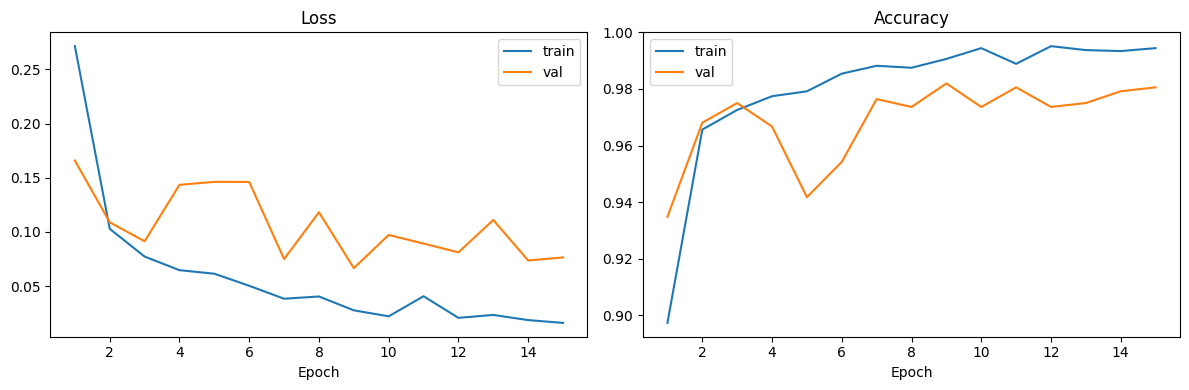

In [131]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Evaluate on validation set

Loads the best checkpoint saved during training and reports precision/recall/F1 per class.

In [132]:
results = evaluate_model()
print(results["report"])


                       precision    recall  f1-score   support

mask_weared_incorrect       0.89      0.74      0.81        23
            with_mask       0.99      0.99      0.99       576
         without_mask       0.95      0.98      0.97       122

             accuracy                           0.98       721
            macro avg       0.95      0.90      0.92       721
         weighted avg       0.98      0.98      0.98       721



## 5. Confusion matrix


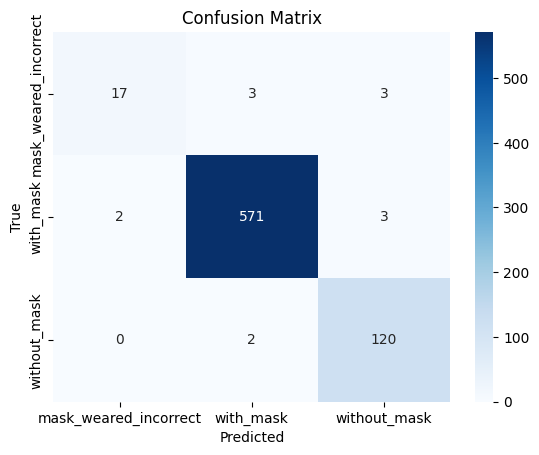

In [133]:
sns.heatmap(
    results["confusion_matrix"], annot=True, fmt="d",
    xticklabels=results["classes"], yticklabels=results["classes"], cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
